# Technical Indicators & Strategy Backtesting with Alpaca

**Homework 2 — Final Report**

Using 5+ years of daily OHLCV data from Alpaca, we implement technical indicators, build a reusable long-only backtesting engine, and compare four strategies (Buy & Hold, Trend Following, Mean Reversion, and a Custom strategy) on a risk-adjusted basis.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from src.data import get_daily_ohlcv
from src.indicators import add_indicators
from src.strategies import STRATEGIES
from src.backtest import run_backtest
from src.metrics import metrics_table
from src.plotting import plot_price_signals, plot_equity_curves, plot_drawdowns

pd.set_option('display.width', 120)

## 1. Historical Data

At least 5 years of daily OHLCV bars for a user-selected ticker, from Alpaca.

In [2]:
TICKER = 'AAPL'   # try MSFT, SPY, QQQ, NVDA
df = get_daily_ohlcv(TICKER, years=5)
print(f"{len(df)} bars: {df.index[0].date()} -> {df.index[-1].date()}")
df.head()

1258 bars: 2021-06-28 -> 2026-07-01


,open,high,low,close,volume
date,,,,,
2021-06-28 04:00:00,133.36,135.24,133.36,134.785,1236447.0
2021-06-29 04:00:00,134.70,136.49,134.36,136.330,2124840.0
2021-06-30 04:00:00,136.12,137.39,135.92,136.880,1360610.0
2021-07-01 04:00:00,136.57,137.31,135.77,137.250,1142155.0
2021-07-02 04:00:00,137.93,140.00,137.75,139.925,1513546.0


## 2. Technical Indicators

11 indicators across all four categories — Trend (SMA, EMA, MACD, ADX), Momentum (RSI, Stochastic, Williams %R), Volatility (Bollinger Bands, ATR), Volume (OBV, CMF).

In [3]:
df = add_indicators(df)
df[['close', 'sma50', 'ema200', 'macd', 'adx', 'rsi', 'bb_upper', 'bb_lower', 'atr', 'obv', 'cmf']].tail()

,close,sma50,ema200,macd,adx,rsi,bb_upper,bb_lower,atr,obv,cmf
date,,,,,,,,,,,
2026-06-25 04:00:00,275.21,291.1384,267.776753,-1.573208,23.838010,32.142293,319.491329,279.938171,7.854568,31685980.0,-0.401503
2026-06-26 04:00:00,281.31,291.4384,267.911412,-2.440500,24.927781,38.841979,318.604602,277.710898,8.129241,36803761.0,-0.371660
2026-06-29 04:00:00,281.69,291.8057,268.048513,-3.061877,25.418941,39.244399,317.259510,276.023990,8.155724,39189801.0,-0.393079
2026-06-30 04:00:00,289.24,292.1864,268.259373,-2.911538,25.543874,46.742562,316.139422,275.441578,8.230315,40766122.0,-0.338720
2026-07-01 04:00:00,294.42,292.6136,268.519678,-2.347352,24.386778,51.193145,312.935821,276.567679,8.169221,43194611.0,-0.334610


## 3. Trading Strategies

**Strategy 1 — Trend Following** (Trend): buy when `MACD > signal` **and** `ADX > 25`; sell when `MACD < signal`.

**Strategy 2 — Mean Reversion** (Momentum + Volatility): buy when `RSI < 30` **and** price below the lower Bollinger Band; sell when `RSI > 70` **and** price above the upper band.

**Strategy 3 — Custom** (Trend + Momentum + Volume): buy when `EMA50 > EMA200` **and** `RSI > 50` **and** `CMF > 0`; exit when the trend breaks (`EMA50 < EMA200`) or momentum fades (`RSI < 45`). Combines three indicators from three different categories.

In [4]:
results = {name: run_backtest(df, strat(df), initial_capital=100_000)
           for name, strat in STRATEGIES.items()}
print('Strategies backtested:', list(results))

Strategies backtested: ['Buy & Hold', 'Trend Following', 'Mean Reversion', 'Custom Strategy']


## 4. Backtesting Engine

Initial capital \$100,000, long-only, no leverage, no shorting. Signals act on the *next* bar (no look-ahead). The engine tracks portfolio value, daily returns, and every round-trip trade.

In [5]:
tf = results['Trend Following']
print('Final portfolio value (Trend Following): ${:,.0f}'.format(tf.equity.iloc[-1]))
print('Number of trades:', len(tf.trades))
tf.trades.head()

Final portfolio value (Trend Following): $110,827
Number of trades: 37


,entry_date,exit_date,entry_price,exit_price,return
0,2021-06-30 04:00:00,2021-07-29 04:00:00,136.880,145.610,0.063778
1,2021-08-17 04:00:00,2021-08-19 04:00:00,150.225,146.710,-0.023398
2,2021-10-15 04:00:00,2021-11-11 05:00:00,144.770,147.835,0.021172
3,2021-11-24 05:00:00,2021-12-20 05:00:00,162.000,169.720,0.047654
4,2022-03-21 04:00:00,2022-04-11 04:00:00,165.380,165.790,0.002479


## 5. Performance Metrics

Total Return, CAGR, Volatility, Sharpe, Sortino, Max Drawdown, and Win Rate for each strategy.

In [6]:
table = metrics_table(results)
table

,Total Return,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Win Rate,Trades
Buy & Hold,118.44%,16.94%,27.56%,0.71,1.02,-33.32%,100.00%,1
Trend Following,10.83%,2.08%,14.08%,0.22,0.18,-25.01%,45.95%,37
Mean Reversion,64.70%,10.51%,18.85%,0.62,0.58,-22.79%,100.00%,5
Custom Strategy,27.38%,4.97%,15.26%,0.39,0.39,-21.49%,33.33%,24


## 6. Visualizations

### 6a. Price chart with indicators & buy/sell signals

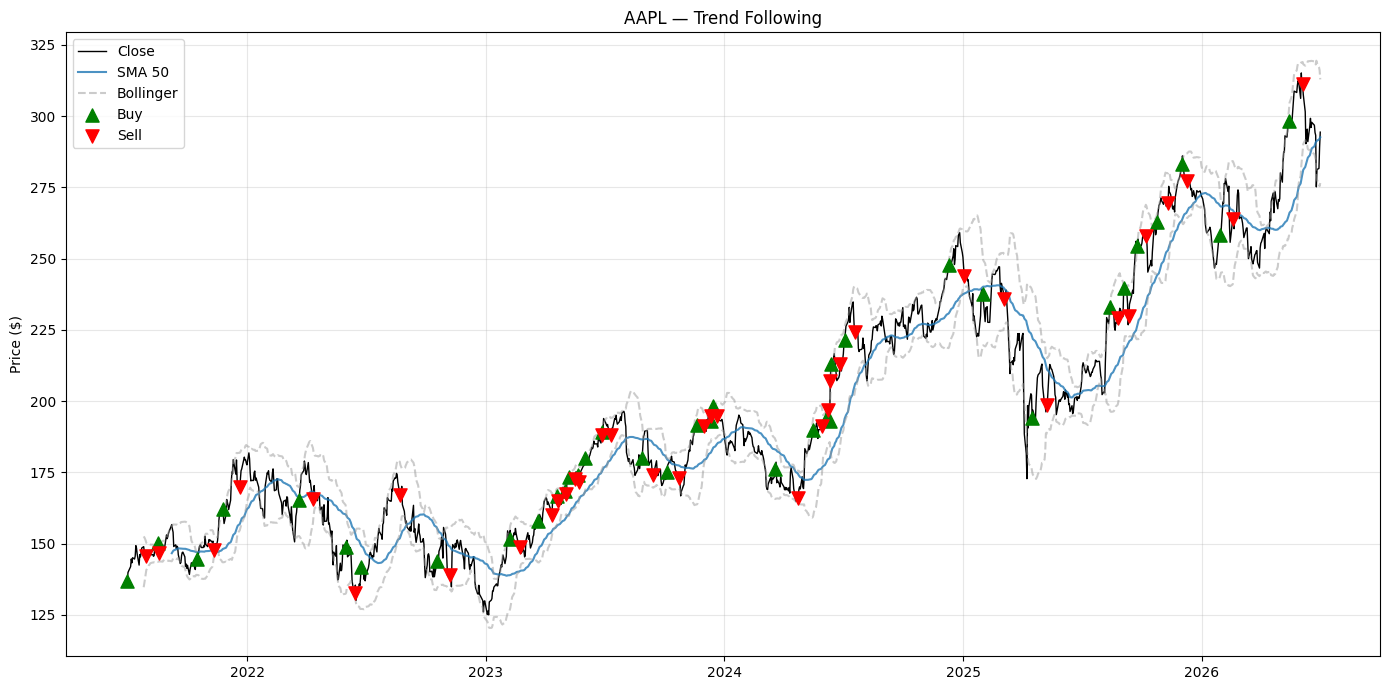

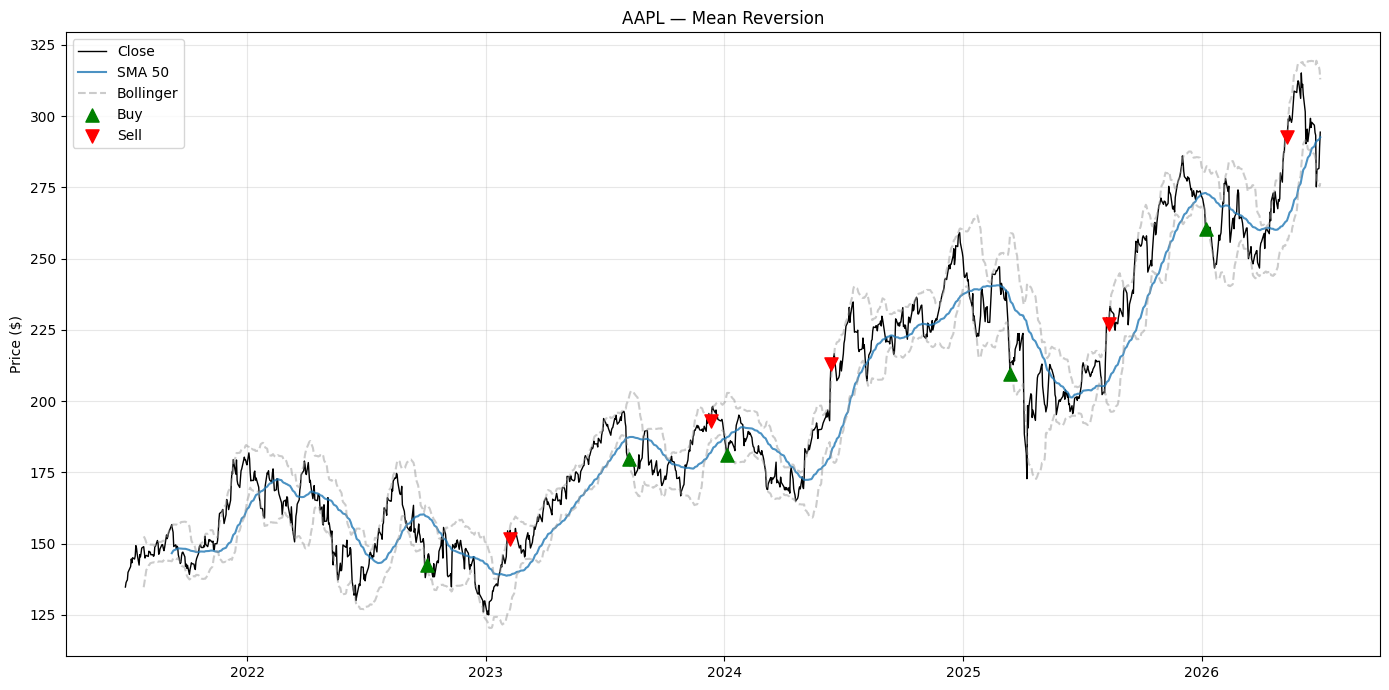

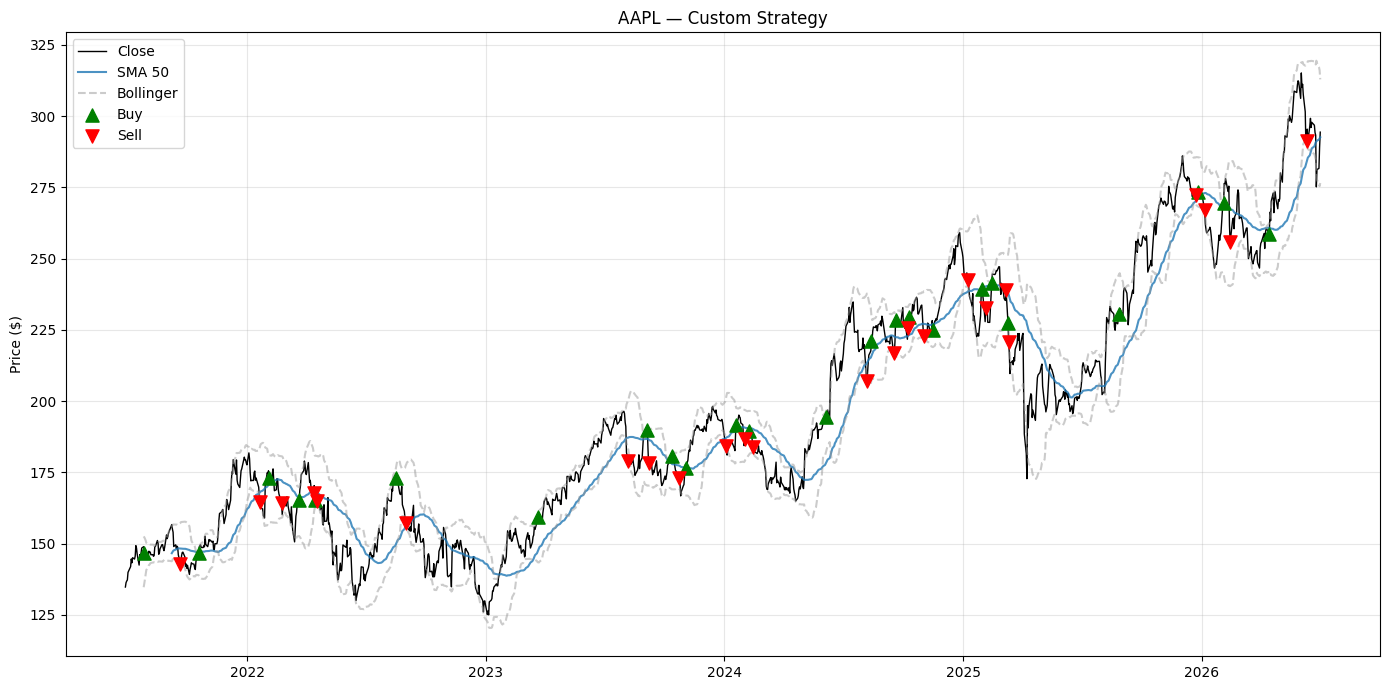

In [7]:
for name in ['Trend Following', 'Mean Reversion', 'Custom Strategy']:
    plot_price_signals(df, results[name], f'{TICKER} — {name}')
    plt.show()

### 6b. Equity curves — Buy & Hold vs. all strategies

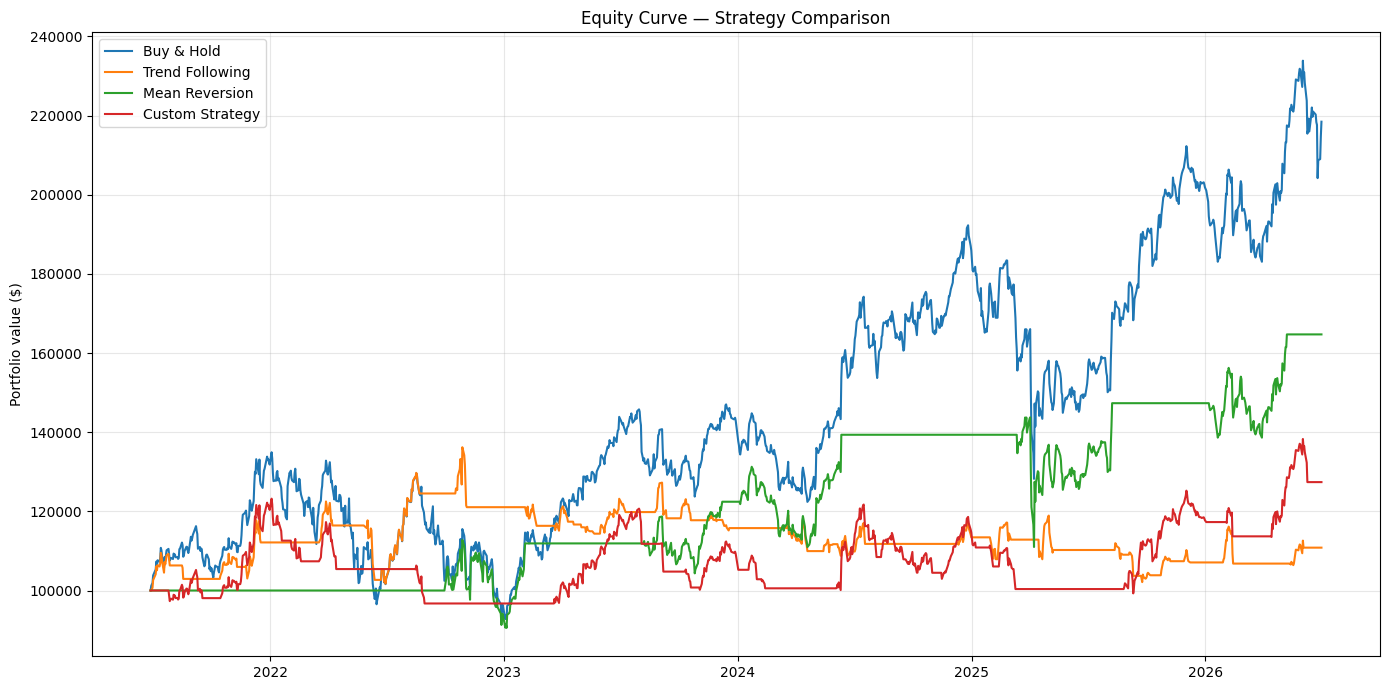

In [8]:
plot_equity_curves(results)
plt.show()

### 6c. Drawdown comparison

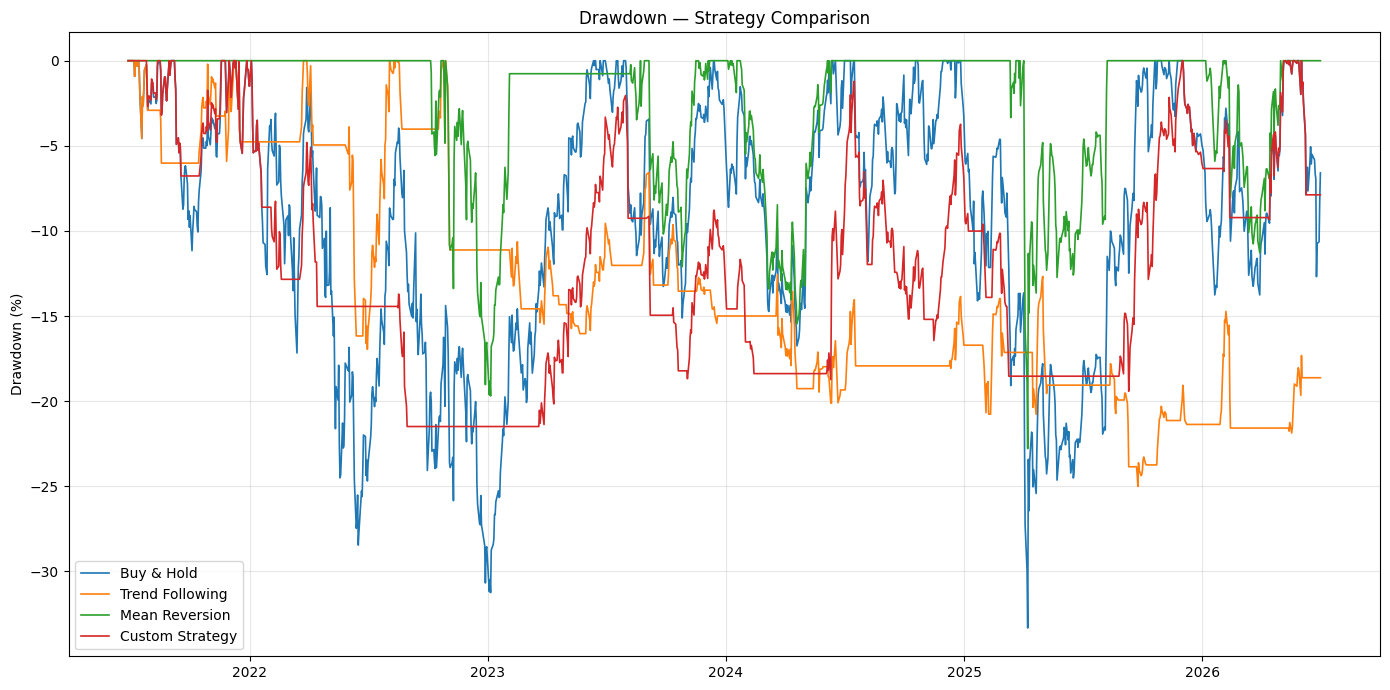

In [9]:
plot_drawdowns(results)
plt.show()

## 7. Final Report & Discussion

See the performance table in section 5 and the equity/drawdown charts above.

**Reading the results (AAPL, 5y):**

- **Buy & Hold** delivers the highest total return but with the deepest drawdown and full market exposure at all times — a high-return, high-risk baseline.
- **Trend Following** (MACD + ADX) trades frequently and cuts exposure in choppy regimes, which lowers volatility and drawdown but also caps upside; its Sharpe trails Buy & Hold when the underlying trends strongly upward.
- **Mean Reversion** (RSI + Bollinger) trades rarely — it only buys deep oversold dips — so it spends most of the period in cash, producing a smoother curve and a competitive Sharpe with a much smaller drawdown.
- **Custom** (EMA regime + RSI + CMF) blends trend, momentum, and volume to stay long only in confirmed uptrends with accumulation, trimming the worst drawdowns at the cost of some return.

**Which is best on a risk-adjusted basis?** Compare the **Sharpe** and **Sortino** columns together with **Max Drawdown**: the strategy with the highest Sharpe *and* a shallower drawdown than Buy & Hold is the best risk-adjusted performer for this ticker and window. Results vary by ticker — re-run the notebook with `TICKER = 'QQQ'`, `'NVDA'`, etc. to compare.

*Note:* results are gross of commissions, slippage, and taxes; paper-quality daily bars are used.